In [1]:
import qiskit
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile, assemble
from qiskit_aer import Aer
from qiskit_aer.noise import NoiseModel

from qiskit_ibm_runtime.fake_provider import FakeProvider
from qiskit_ibm_runtime.fake_provider import FakeNairobi

from qiskit.circuit import QuantumCircuit, Parameter

# from qiskit.providers.fake_provider import FakeNairobi
# from qiskit.opflow.primitive_ops import PauliSumOp, TaperedPauliSumOp
from qiskit.quantum_info import SparsePauliOp, PauliList, Pauli
from qiskit.circuit.library import TwoLocal, EfficientSU2
# from qiskit.providers.aer import QasmSimulator
# from qiskit.algorithms.optimizers import SPSA

from qiskit.circuit.library import ZGate

from qiskit.result import marginal_counts

import matplotlib.pyplot as plt


import numpy as np
import random
import pandas as pd
import time
import sys

In [2]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [3]:
qiskit.__version__


'1.0.2'

In [4]:
def calc_partition(
    total_qubits: int, 
    qubits_qpu: int, 
    max_qpus: int, 
    verbose=True) -> list[int]:
    
    if max_qpus * qubits_qpu < total_qubits:
        raise ValueError(f"Cannot satisfy {total_qubits} in {max_qpus} QPUs of {qubits_qpu} qubits/QPU")

    num_nodes = int(np.ceil(total_qubits/qubits_qpu))

    if num_nodes > qubits_qpu:
        raise ValueError(f"Router requires {num_nodes} qubits -> larger than QPUs")

    qubits_left = total_qubits
    node_qubits = [0] * num_nodes

    for i in range(num_nodes - 1):
        node_qubits[i] = qubits_qpu
        qubits_left -= qubits_qpu

    node_qubits[num_nodes - 1] = qubits_left
    if verbose==True:
        print(f"{num_nodes} nodes required")
        print(f"{node_qubits} qubits in each node")

    return node_qubits

In [5]:
def MCZ(n_qubits):
    if n_qubits == 1:
        return ZGate()
    else:
        return ZGate().control(n_qubits-1)

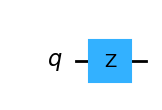

In [6]:
tc = QuantumCircuit(1)
tc.append(MCZ(len([i for i in range(1)] )),[i for i in range(1)] )
tc.draw('mpl')

In [7]:
len([i for i in range(1)] )

1

In [8]:
[i for i in range(1)]

[0]

In [9]:
num_qubits = 3

qubits = calc_partition(num_qubits,2,2)
print(qubits)

2 nodes required
[2, 1] qubits in each node
[2, 1]


In [10]:
# basis == False
# # qubits = [nq,nq,nq,nq,...nq,rest], the distribution of qubits between workers, 
# # where nq is the number of qubits per worker, rest is the ones in the last worker.
# N_workers = len(qubits)
# total_qubits = sum(qubits)
# Nqr = N_workers

# if basis == False:
#     basis = 'Z'*total_qubits

# W = [QuantumRegister(size=qubits[i]+1, name='W'+str(i), bits=None)
#         for i in range(N_workers)]
# w = [ClassicalRegister(size=qubits[i]+1, name='w'+str(i), bits=None)
# for i in range(N_workers)]

# R = QuantumRegister(size=Nqr, name='R', bits=None)
# r = ClassicalRegister(size=Nqr, name='r', bits=None)

# circ = QuantumCircuit()
# for i in range(N_workers):
#     circ.add_register(W[i])
#     circ.add_register(w[i])
# circ.add_register(R)
# circ.add_register(r)

# """
# The next block just performs the CCZ gate, so for more general multi-controlled gates,
# we may want to change the basis here
# """
# for i in range(N_workers):
#     if basis[i] == 'X':
#         circ.h(W[i][1])

#     # Then create the initial EPR+H to be in the appropriate basis
# # for i in range(N_workers):
#     circ.h(W[i][0])
#     circ.cx(W[i][0],R[i])
#     circ.h(W[i][0])

#     # Entangle the EPR and the second qubit of each node using CCC..Z gates
#     circ.append(MCZ(len(W[i])),[W[i][j] for j in range(len(W[i]))] )

#     # Measure in X-basis the Comm qubits, and classically control CC..Z gate onto the router
# # for i in range(N_workers):
#     circ.h(W[i][0])
#     circ.measure(W[i][0],w[i][0])
#     circ.x(R[i]).c_if(w[i][0],1) #?????? c_if for this???     
#     # Also, reset these to 0
#     circ.reset(W[i][0])

# # CCC..Z in the Router
# circ.append(MCZ(len(R)),[R[i] for i in range(len(R))] )


# for i in range(len(R)):
#     circ.measure(R[i],r[i])
#         # Also, reset these to 0
#     circ.reset(R[i])

#     circ.append(MCZ(len(W[i])-1).c_if(r[i],1),[W[i][j] for j in range(1,len(W[i]))] )
# for i in range(N_workers):
#     if basis[i] == 'X':
#         circ.h(W[i][1])



In [11]:
def regularOracle(qubits, target):
    
    # First, create the circuit, then add the appropriate X gates according to the target state, then add DMCZ, and again X gates

    circ = QuantumCircuit(qubits)


    # This is to apply the X gates to the appropriate register
    for (i,t) in enumerate(target):
        if t=='0':     
            circ.x(i)
    circ.barrier()
    circMCZ = MCZ(qubits)
    circ=circ&circMCZ
    circ.barrier()
    for (i,t) in enumerate(target):
        if t=='0':     
            circ.x(i)
    return circ

def regularDiffuser(qubits):
    
    # First, create the circuit, then add the appropriate H gates according to the target state, then add DMCZ, and again H gates

    circ = QuantumCircuit(qubits)
    
    # This is to apply the H gates to all data qubits 
    for i in range(qubits):
        circ.h(i)
    circ.barrier()
    circMCZ = MCZ(qubits)
    circ=circ&circMCZ
    circ.barrier()
    for i in range(qubits):
        circ.h(i)
        
    return circ


def regularGrover(target, num_layers=None, verbose=True):
    
    num_qubits = len(target)    
    
    # If not specified, use Nielsen & Chuang estimation for optimal number of layers'?
    if num_layers==None:
        num_layers = int(np.floor((np.pi / 4) * np.sqrt(2 ** num_qubits) - 0.5))
        
    if verbose==True:        
        print('Number of layers: ',num_layers)


    # First, create the circuit, start in the state |-> in the data qubits, then add for each layer oracle+diffuser 

    circ = QuantumCircuit(num_qubits,num_qubits)
 
    
    for i in range(num_qubits):
        circ.x(i)    
        circ.h(i)    
            
    circ.barrier()
    oracle = regularOracle(num_qubits, target)
    
    diffuser = regularDiffuser(num_qubits)
    
    for layer in range(num_layers):
        circ = circ&oracle
        circ.barrier()
        
        circ = circ&diffuser
        circ.barrier()
        circ.barrier()

        
    # Measure the data qubits
    for i in range(num_qubits):
        circ.measure(i,i)
    


    return circ

In [12]:
def guilleMCZ(qubits, 
              basis = False):
    # qubits = [nq,nq,nq,nq,...nq,rest], the distribution of qubits between workers, 
    # where nq is the number of qubits per worker, rest is the ones in the last worker.
    N_workers = len(qubits)
    total_qubits = sum(qubits)
    Nqr = N_workers

    if basis == False:
        basis = 'Z'*total_qubits

    W = [QuantumRegister(size=qubits[i]+1, name='W'+str(i), bits=None)
            for i in range(N_workers)]
    w = [ClassicalRegister(size=qubits[i]+1, name='w'+str(i), bits=None)
    for i in range(N_workers)]

    R = QuantumRegister(size=Nqr, name='R', bits=None)
    r = ClassicalRegister(size=Nqr, name='r', bits=None)

    circ = QuantumCircuit()
    for i in range(N_workers):
        circ.add_register(W[i])
        circ.add_register(w[i])
    circ.add_register(R)
    circ.add_register(r)

    """
    The next block just performs the CCZ gate, so for more general multi-controlled gates,
    we may want to change the basis here
    """
    for i in range(N_workers):
        if basis[i] == 'X':
            circ.h(W[i][1])

        # Then create the initial EPR+H to be in the appropriate basis
    # for i in range(N_workers):
        circ.h(W[i][0])
        circ.cx(W[i][0],R[i])
        circ.h(W[i][0])

        # Entangle the EPR and the second qubit of each node using CCC..Z gates
        circ.append(MCZ(len(W[i])),[W[i][j] for j in range(len(W[i]))] )

        # Measure in X-basis the Comm qubits, and classically control CC..Z gate onto the router
    # for i in range(N_workers):
        circ.h(W[i][0])
        circ.measure(W[i][0],w[i][0])
        circ.x(R[i]).c_if(w[i][0],1) 
        
        # Also, reset these to 0
        circ.x(W[i][0]).c_if(w[i][0],1)
#         circ.reset(W[i][0])

    # CCC..Z in the Router
    circ.append(MCZ(len(R)),[R[i] for i in range(len(R))] )


    for i in range(len(R)):
        circ.h(R[i])        
        circ.measure(R[i],r[i])
            # Also, reset these to 0
        circ.x(R[i]).c_if(r[i],1)
#         circ.reset(R[i])

        circ.append(MCZ(len(W[i])-1).c_if(r[i],1),[W[i][j] for j in range(1,len(W[i]))] )
    for i in range(N_workers):
        if basis[i] == 'X':
            circ.h(W[i][1])
    return circ

def dist_index(qubits, n):
    cumulative_sum = 0
    
    for i, partition_size in enumerate(qubits):
        previous_sum = cumulative_sum
        cumulative_sum += partition_size
        
        if n <= cumulative_sum:
            # Determine the i-th element in the found partition
            ith_element = n - previous_sum
            return i + 1, ith_element  # Returns partition index (1-based) and i-th element (1-based)
    
    return -1, -1  # If n is out of bounds

def guilleOracle(qubits, target):
    
    # First, create the circuit, then add the appropriate X gates according to the target state, then add DMCZ, and again X gates
    N_workers = len(qubits)

    circ, W, w, R, r = guilleStart(qubits)
    

    # This is to apply the X gates to the appropriate register
    for (i,t) in enumerate(target):
        if t=='0':
            (iw, iq) = dist_index(qubits,i+1)        
            circ.x(W[iw-1][iq])
    circ.barrier()
    circMCZ = guilleMCZ(qubits)
    circ=circ&circMCZ
    circ.barrier()
    for (i,t) in enumerate(target):
        if t=='0':
            (iw, iq) = dist_index(qubits,i+1)        
            circ.x(W[iw-1][iq])
    return circ

def guilleDiffuser(qubits):
    
    # First, create the circuit, then add the appropriate H gates according to the target state, then add DMCZ, and again H gates
    N_workers = len(qubits)

    circ, W, w, R, r = guilleStart(qubits)
    
    # This is to apply the H gates to all data qubits 
    for iw in range(N_workers):
        for iq in range(1,len(W[iw])):
            circ.h(W[iw][iq])
    circ.barrier()
    circMCZ = guilleMCZ(qubits)
    circ=circ&circMCZ
    circ.barrier()
    for iw in range(N_workers):
        for iq in range(1,len(W[iw])):
            circ.h(W[iw][iq])

        
    return circ

def guilleStart(qubits):
    
    N_workers = len(qubits)

    W = [QuantumRegister(size=qubits[i]+1, name='W'+str(i), bits=None)
            for i in range(N_workers)]
    w = [ClassicalRegister(size=qubits[i]+1, name='w'+str(i), bits=None)
            for i in range(N_workers)]

    R = QuantumRegister(size=N_workers, name='R', bits=None)
    r = ClassicalRegister(size=N_workers, name='r', bits=None)    

    circ = QuantumCircuit()
    for i in range(N_workers):
        circ.add_register(W[i])
        circ.add_register(w[i])
        
    circ.add_register(R)
    circ.add_register(r)
    return circ, W, w, R, r

def guilleGrover(qubits_per_node, num_nodes, target, num_layers=None, verbose=True):
    
    num_qubits = len(target)    
    
    # If not specified, use Nielsen & Chuang estimation for optimal number of layers'?
    if num_layers==None:
        num_layers = int(np.floor((np.pi / 4) * np.sqrt(2 ** num_qubits) - 0.5))
    if verbose==True:
        print('Number of layers: ',num_layers)
    qubits = calc_partition(num_qubits,qubits_per_node,num_nodes, verbose)

    # First, create the circuit, start in the state |-> in the data qubits, then add for each layer oracle+diffuser 
    N_workers = len(qubits)
    
    circ, W, w, R, r = guilleStart(qubits)

    if verbose==True:
    
        print('Number of qubits in Router: ',N_workers)

        print('Total number of qubits in circuit: ',circ.num_qubits)

        print('Total number of EPR: ', 2*num_layers*N_workers)

        print('Total number of classical bits: ', 4*num_layers*N_workers)    
    
    for iw in range(N_workers):
        for iq in range(1,len(W[iw])):
            circ.x(W[iw][iq])    
            circ.h(W[iw][iq])    
            
    circ.barrier()
    oracle = guilleOracle(qubits, target)
    
    diffuser = guilleDiffuser(qubits)
    
    for layer in range(num_layers):
        circ = circ&oracle
        circ.barrier()
        
        circ = circ&diffuser
        circ.barrier()
        circ.barrier()

        
    # Measure the data qubits
    for iw in range(N_workers):
        for iq in range(1,len(W[iw])):
            circ.measure(W[iw][iq],w[iw][iq])
    
    data_qubits = [] 
    
    d = 0
    for iw in qubits:
        for iq in range(iw+1):

            if iq != 0:
                data_qubits.append(d)
            d +=1            
    if verbose==True:
        print('Data qubits: ',data_qubits)
    return circ, data_qubits



In [34]:

qubits_per_node = 3
num_nodes = 10

target = '11011100'
num_qubits = len(target)
num_layers = None


ccc, data_qubits = guilleGrover(qubits_per_node,
                                num_nodes, 
                                target, num_layers=num_layers)

Number of layers:  12
3 nodes required
[3, 3, 2] qubits in each node
Number of qubits in Router:  3
Total number of qubits in circuit:  14
Total number of EPR:  72
Total number of classical bits:  144
Data qubits:  [1, 2, 3, 5, 6, 7, 9, 10]


In [31]:
qubits = calc_partition(num_qubits,
                        qubits_per_node,
                        num_nodes, 
                        verbose=False)
qubits

[3, 3, 2]

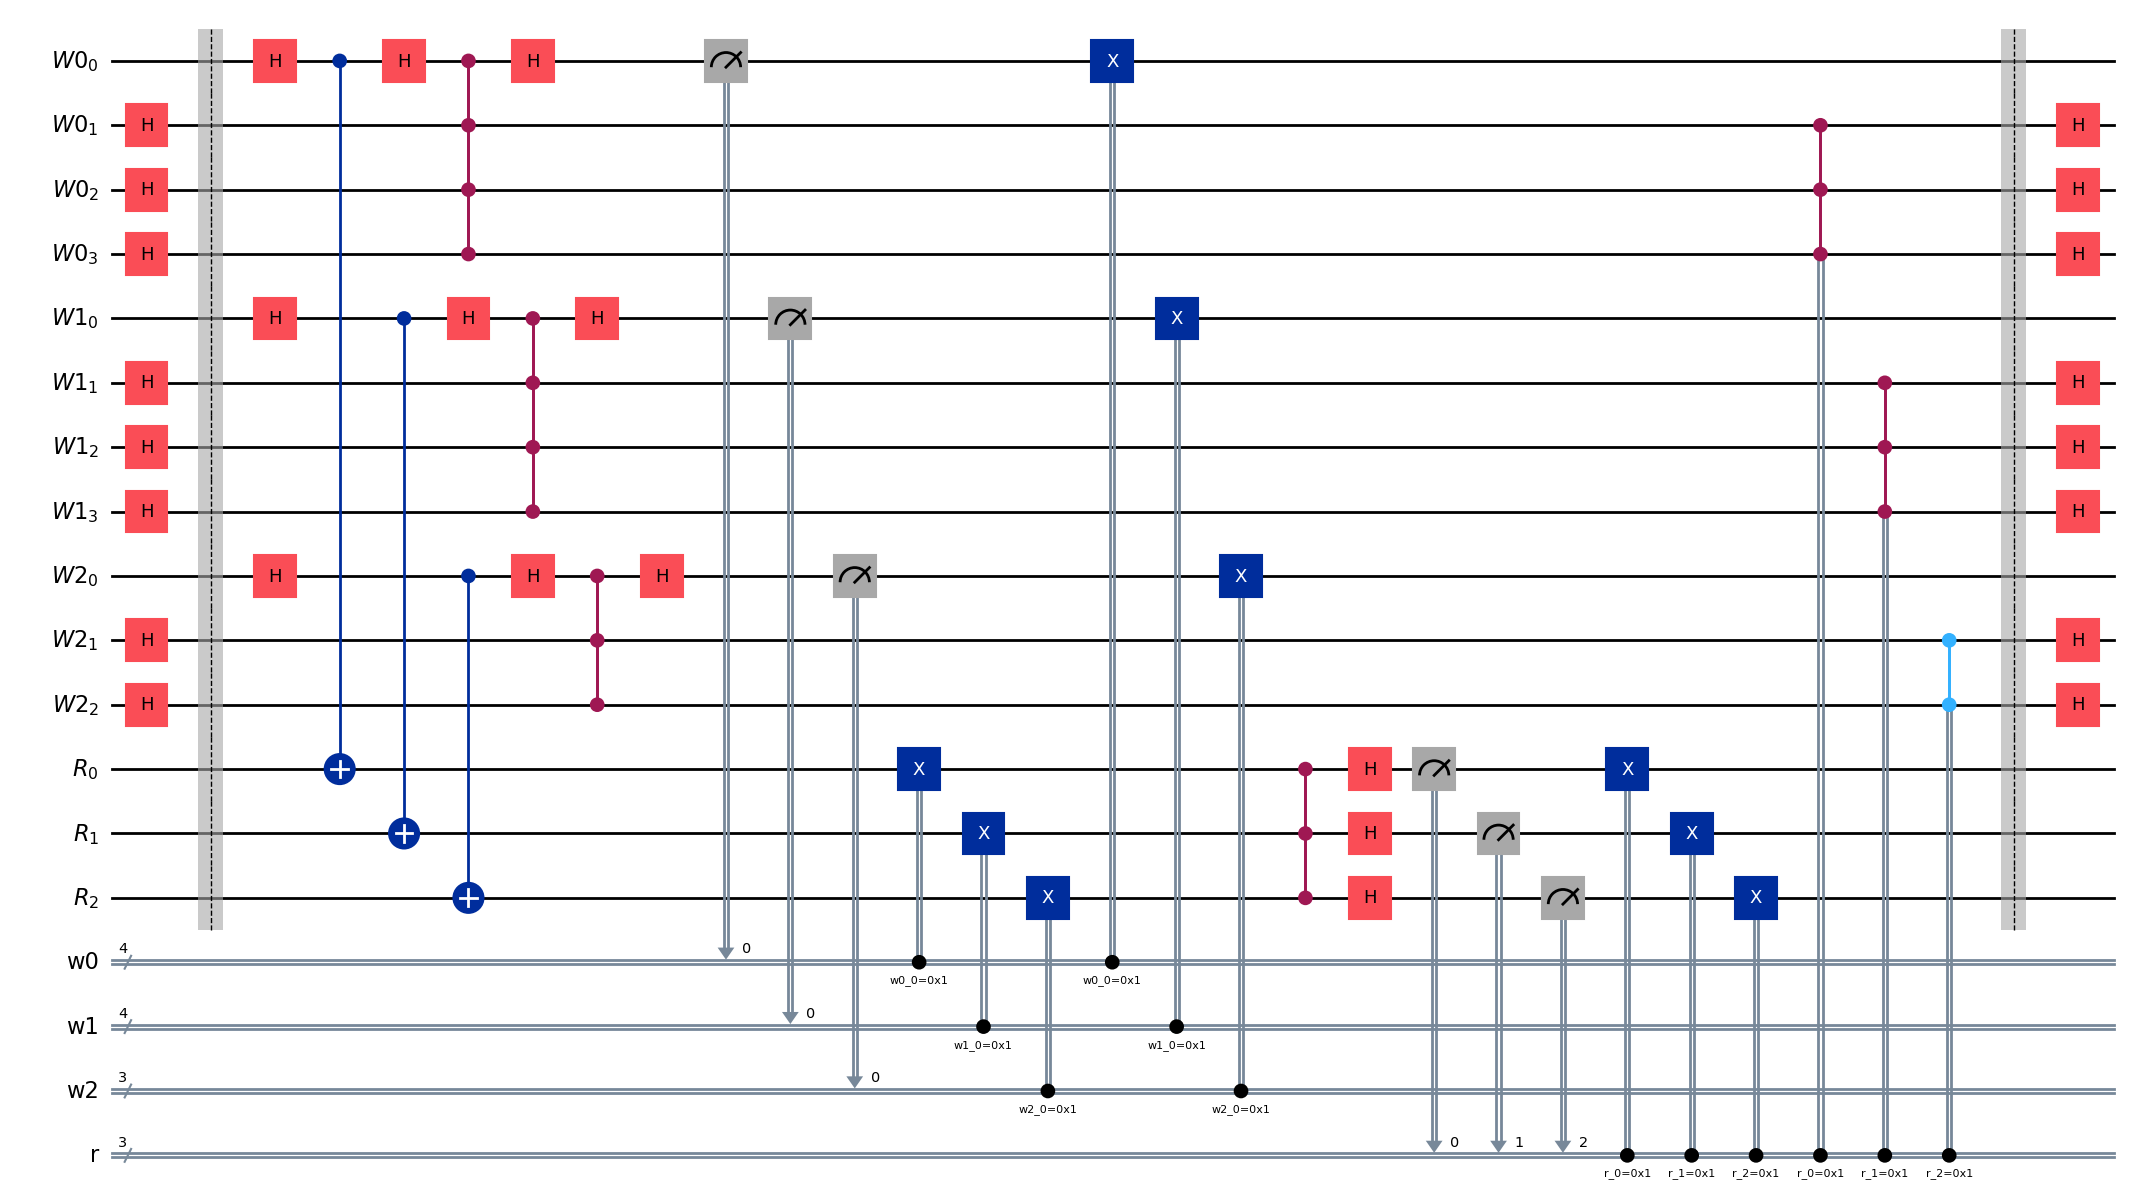

In [32]:
guilleDiffuser(qubits).draw('mpl',fold=-1)

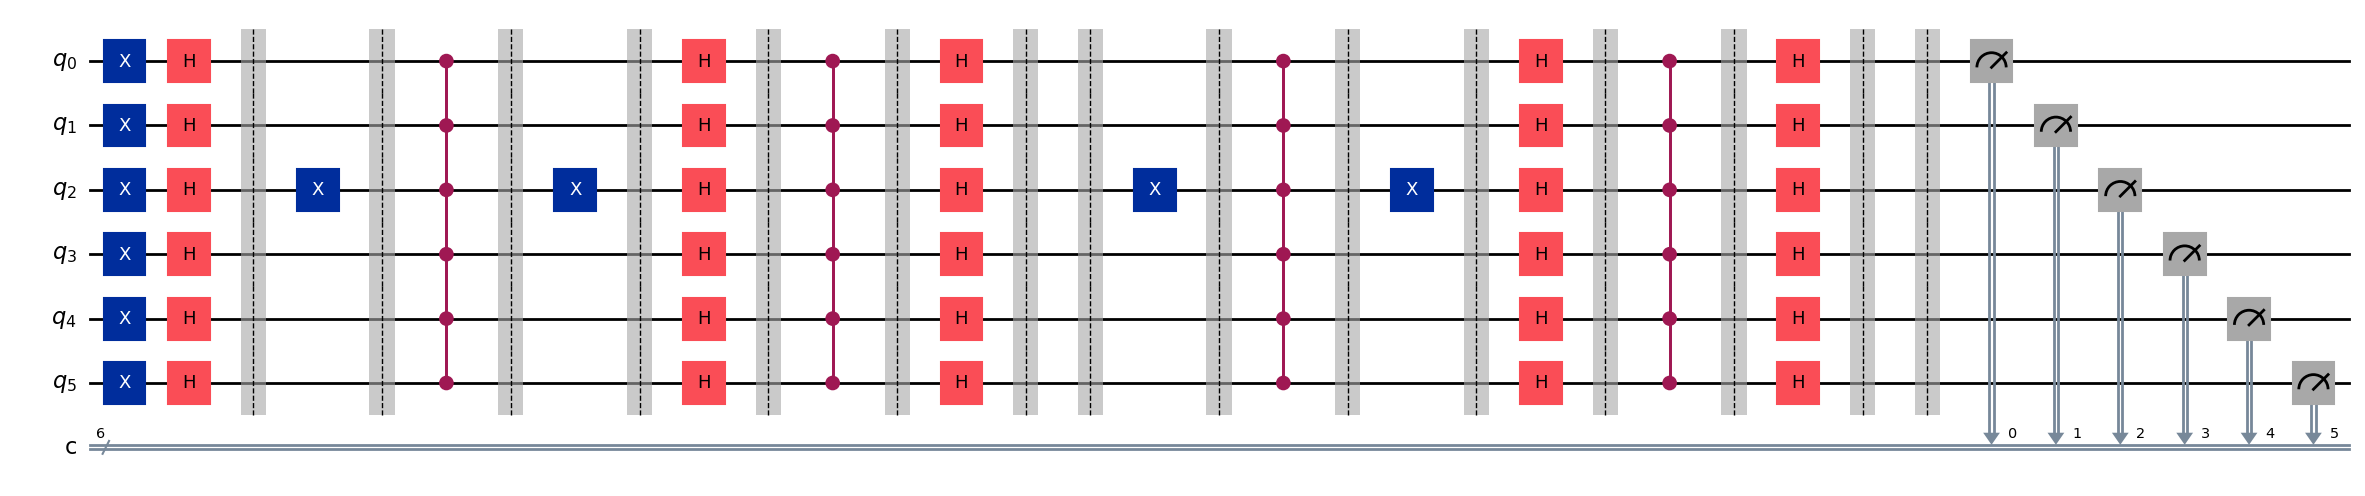

In [16]:
cc0 = regularGrover(target,num_layers=2, verbose=False)
cc0.draw('mpl', fold=-1)

In [ ]:
backend = Aer.get_backend('aer_simulator')
NSHOTS = 1000

result = backend.run(transpile(ccc, backend), shots = NSHOTS).result()

counts = marginal_counts(result,data_qubits).get_counts()

scounts= dict(sorted(counts.items()))


maxkey = max(scounts, key=scounts.get)
maxval = scounts[maxkey]
probkey = 100*maxval/NSHOTS

print(maxkey)
print(maxval)
print(probkey,'%')

plt.bar(scounts.keys(),scounts.values())
plt.xticks(range(len(scounts.keys())), scounts.keys(), rotation=75)
plt.show()

In [18]:
cc0 = regularGrover(target,num_layers=num_layers)

Number of layers:  3


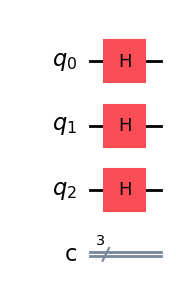

In [19]:
qc1 = QuantumCircuit(5,5)
for q in range(5):
    qc1.x(q)

qc2 = QuantumCircuit(3,3)
for q in range(3):
    qc2.h(q)

qc2.draw('mpl')

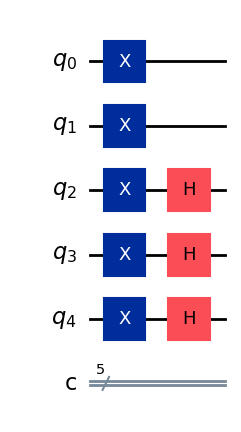

In [20]:
qc3 = qc1.compose(qc2, [2, 3, 4], inplace=False)

qc3.draw('mpl')

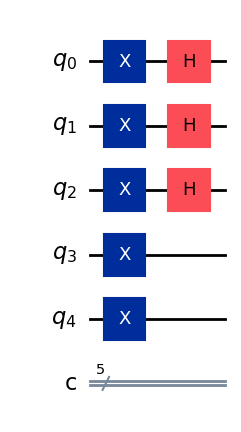

In [21]:
(qc1&qc2).draw('mpl')

In [22]:
target

'110111'

In [23]:
# cc0.draw('mpl')

111011
601
60.1 %


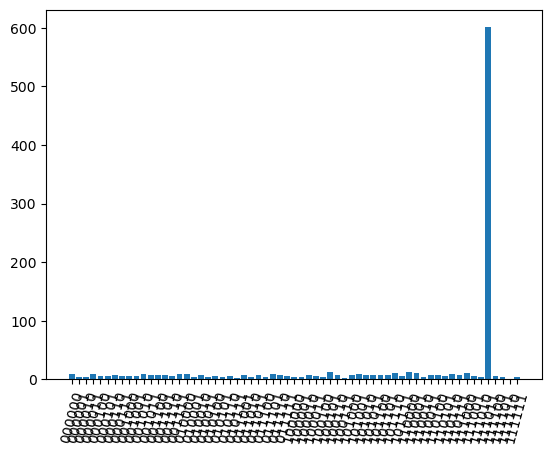

In [24]:
backend = Aer.get_backend('aer_simulator')
NSHOTS = 1000

result0 = backend.run(transpile(cc0, backend), shots = NSHOTS).result()

counts0 = result0.get_counts()

scounts= dict(sorted(counts0.items()))


maxkey = max(scounts, key=scounts.get)
maxval = scounts[maxkey]
probkey = 100*maxval/NSHOTS

print(maxkey)
print(maxval)
print(probkey,'%')

plt.bar(scounts.keys(),scounts.values())
plt.xticks(range(len(scounts.keys())), scounts.keys(), rotation=75)
plt.show()

## ANALISIS OF DEPTH

In [25]:
def decimal_to_binary(decimal, bits):
    # Calculate the maximum and minimum values that can fit within the specified bit length
    min_value = -(2**(bits))
    max_value = 2**(bits) - 1
    
    # Check if the number can be represented within the given number of bits
    if not (min_value <= decimal <= max_value):
        raise ValueError(f"The number {decimal} cannot be represented with {bits} bits.")
    
    # Convert the decimal to binary, masking with (2**bits - 1) for two's complement representation
    binary_str = bin(decimal & (2**bits - 1))[2:]
    return binary_str.zfill(bits)



In [26]:
from tqdm.notebook import tqdm

In [27]:
num_qubits = 8
qubits_per_node = 3
num_nodes = 10

depth_reg = {}
depth_dis = {}

cx_reg = {}
cx_dis = {}

for num_qubits in tqdm(range(4,13)):
    dr = {}
    dd = {}
    
    cxr = {}
    cxd = {}
#     for qubits_per_node in tqdm(range(2,int(np.ceil(num_qubits/2)+1)), leave=False):
    for qubits_per_node in tqdm([int(np.ceil(num_qubits/n)) for n in [2,3,4]], leave=False):

        
        num_nodes = int(np.ceil(num_qubits/qubits_per_node))
        if num_nodes <= qubits_per_node:

            target = decimal_to_binary(2**num_qubits-1,num_qubits)
            num_layers = 1


            ccc, data_qubits = guilleGrover(qubits_per_node,num_nodes, 
                                            target, num_layers=num_layers, verbose=False)



            tcc = transpile(ccc, backend, basis_gates = {'cx','h','x','z','y','u', 't'})

            dd[qubits_per_node] = tcc.num_qubits,tcc.depth(),tcc.num_nonlocal_gates()
        
    cc0 = regularGrover(target,num_layers=num_layers, verbose=False)
    tc0 = transpile(cc0, backend, basis_gates = {'cx','h','x','z','y','u', 't'})
        
    depth_dis[num_qubits]=dd
    depth_reg[num_qubits]=tc0.num_qubits,tc0.depth(),tc0.num_nonlocal_gates()

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]


KeyboardInterrupt



In [ ]:
cc00 = regularGrover('0101',num_layers=1, verbose=False)
tc00 = transpile(cc00, backend, basis_gates = {'cx','h','x','z','y','u', 't'})

In [ ]:
cc00.draw('mpl')

In [ ]:
keys = [k for k in depth_reg.keys()]

qreg = []
dreg = []
cxreg = []

for k1,v1 in depth_reg.items():
    qreg.append(v1[0])
    dreg.append(v1[1])
    cxreg.append(v1[2])
    
qdis = []
ddis = []
cxdis = []

for k1,v1 in depth_dis.items():
    fuu = []
    foo = []
    fee = []
    for k2,v2 in v1.items():
        fuu.append(v2[0])
        foo.append(v2[1])
        fee.append(v2[2])
    qdis.append(fuu)
    ddis.append(foo)
    cxdis.append(fee)

In [ ]:
ddis_2 = [d[0] for d in ddis] 
ddis_3 = [d[1] for d in ddis if len(d)>1] 
ddis_4 = [d[2] for d in ddis if len(d)>2] 

qdis_2 = [d[0] for d in qdis] 
qdis_3 = [d[1] for d in qdis if len(d)>1] 
qdis_4 = [d[2] for d in qdis if len(d)>2] 

cxdis_2 = [d[0] for d in cxdis] 
cxdis_3 = [d[1] for d in cxdis if len(d)>1] 
cxdis_4 = [d[2] for d in cxdis if len(d)>2] 

keys_2 = [k for (i,k) in enumerate(keys) if len(ddis[i])>0]
keys_3 = [k for (i,k) in enumerate(keys) if len(ddis[i])>1]
keys_4 = [k for (i,k) in enumerate(keys) if len(ddis[i])>2]

ancilla_2 = (np.array(qdis_2)-np.array(keys_2))
ancilla_3 = (np.array(qdis_3)-np.array(keys_3))
ancilla_4 = (np.array(qdis_4)-np.array(keys_4))

In [ ]:
layers_2 = 1
layers_3 = 1
layers_4 = 1

epr_2 = ancilla_2/2*layers_2
epr_3 = ancilla_3/2*layers_3
epr_4 = ancilla_4/2*layers_4

In [ ]:
def cxcount_nielsen(n):
    return 6*n-12

def cxcount_nielsen_dist(n, parts):
    # Divide the CCC...X gate of n qubits into 2 of n/2+1 qubits, and 2 of n/2 qubits, that are classically controlled and thus only appear 1/2 of the times 
    return int(parts*cxcount_nielsen(n/parts+1)+(1/1)*parts*cxcount_nielsen(n/parts))

def cxcount_maslov(n):
    if n%2 == 0:
        return 3*n-9
    else:
        return 3*n-6

print(cxcount_nielsen(16),cxcount_nielsen_dist(16,2)/2)

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))


ax[0,0].plot(keys, dreg, 'C0', marker='.')
ax[0,0].plot(keys_2, ddis_2, 'C1', marker='.')
ax[0,0].plot(keys_3, ddis_3, 'C2', marker='.')
ax[0,0].plot(keys_4, ddis_4, 'C3', marker='.')
ax[0,0].legend(['Regular Grover','Dist Grover (N/2)','Dist Grover (N/3)','Dist Grover (N/4)'])
ax[0,0].set_yscale('log')
ax[0,0].set_xlabel('Nq in original Grover')
ax[0,0].set_ylabel('Depth of circuit')

ax[0,1].plot(keys, cxreg, 'C0', marker='.')
ax[0,1].plot(keys_2, cxdis_2, 'C1', marker='.')
ax[0,1].plot(keys_3, cxdis_3, 'C2', marker='.')
ax[0,1].plot(keys_4, cxdis_4, 'C3', marker='.')
ax[0,1].plot(keys_2, [2*cxcount_nielsen(k) for k in keys_2], 'C4--', marker='.')
# ax[0,1].plot(keys_2, [2*cxcount_maslov(k) for k in keys_2], 'C5--', marker='.')


ax[0,1].legend(['Regular Grover','Dist Grover (N/2)','Dist Grover (N/3)','Dist Grover (N/4)','Nielsen Decomp (full)'])
# ax[0,1].set_yscale('log')
ax[0,1].set_ylim([0,1000])
ax[0,1].set_xlabel('Nq in original Grover')
ax[0,1].set_ylabel('CX count')

ax[1,0].plot(keys_2, qdis_2, 'C1', marker='.')
ax[1,0].plot(keys_3, qdis_3, 'C2', marker='.')
ax[1,0].plot(keys_4, qdis_4, 'C3', marker='.')
ax[1,0].legend(['Dist Grover (N/2)','Dist Grover (N/3)','Dist Grover (N/4)'])
ax[1,0].set_xlabel('Nq in original Grover')
ax[1,0].set_ylabel('Total qubits')

ax[1,1].plot(keys_2, epr_2, 'C1', marker='.')
ax[1,1].plot(keys_3, epr_3, 'C2', marker='.')
ax[1,1].plot(keys_4, epr_4, 'C3', marker='.')
ax[1,1].legend(['Dist Grover (N/2)','Dist Grover (N/3)','Dist Grover (N/4)'])
ax[1,1].set_xlabel('Nq in original Grover')
ax[1,1].set_ylabel('EPR needed')

fig.suptitle("Single layer Grover", fontsize=16)

plt.tight_layout() 
plt.show()

In [ ]:
def cxcount_nielsen(n):
    return 6*n-12

def cxcount_maslov(n):
    if n%2 == 0:
        return 3*n-9
    else:
        return 3*n-6

cxcount_nielsen(5)

## MANY LAYERS GROVER

In [ ]:
num_qubits = 8
qubits_per_node = 3
num_nodes = 10

depth_regL = {}
depth_disL = {}

cx_reg = {}
cx_dis = {}

for num_qubits in tqdm(range(4,13)):
    dr = {}
    dd = {}
    
    cxr = {}
    cxd = {}
#     for qubits_per_node in tqdm(range(2,int(np.ceil(num_qubits/2)+1)), leave=False):
    for qubits_per_node in tqdm([int(np.ceil(num_qubits/n)) for n in [2,3]], leave=False):

        
        num_nodes = int(np.ceil(num_qubits/qubits_per_node))
        if num_nodes <= qubits_per_node:

            target = decimal_to_binary(2**num_qubits-1,num_qubits)
            num_layers = None


            ccc, data_qubits = guilleGrover(qubits_per_node,num_nodes, 
                                            target, num_layers=num_layers, verbose=False)



            tcc = transpile(ccc, backend, basis_gates = {'cx','h','x','z','y','u', 't'})

            dd[qubits_per_node] = tcc.num_qubits,tcc.depth(),tcc.num_nonlocal_gates()
        
    cc0 = regularGrover(target,num_layers=num_layers, verbose=False)
    tc0 = transpile(cc0, backend, basis_gates = {'cx','h','x','z','y','u', 't'})
        
    depth_disL[num_qubits]=dd
    depth_regL[num_qubits]=tc0.num_qubits,tc0.depth(),tc0.num_nonlocal_gates()

In [ ]:
keysL = [k for k in depth_regL.keys()]

qregL = []
dregL = []
cxregL = []

for k1,v1 in depth_regL.items():
    qregL.append(v1[0])
    dregL.append(v1[1])
    cxregL.append(v1[2])
    
qdisL = []
ddisL = []
cxdisL = []

for k1,v1 in depth_disL.items():
    fuu = []
    foo = []
    fee = []
    for k2,v2 in v1.items():
        fuu.append(v2[0])
        foo.append(v2[1])
        fee.append(v2[2])
    qdisL.append(fuu)
    ddisL.append(foo)
    cxdisL.append(fee)

In [ ]:
ddis_2L = [d[0] for d in ddisL] 
ddis_3L = [d[1] for d in ddisL if len(d)>1] 
# ddis_4 = [d[2] for d in ddis if len(d)>2] 

qdis_2L = [d[0] for d in qdisL] 
qdis_3L = [d[1] for d in qdisL if len(d)>1] 
# qdis_4 = [d[2] for d in qdis if len(d)>2] 

cxdis_2L = [d[0] for d in cxdisL] 
cxdis_3L = [d[1] for d in cxdisL if len(d)>1] 
# cxdis_4 = [d[2] for d in cxdis if len(d)>2] 

keys_2L = [k for (i,k) in enumerate(keysL) if len(ddisL[i])>0]
keys_3L = [k for (i,k) in enumerate(keysL) if len(ddisL[i])>1]
# keys_4 = [k for (i,k) in enumerate(keys) if len(ddis[i])>2]

ancilla_2L = (np.array(qdis_2L)-np.array(keys_2L))
ancilla_3L = (np.array(qdis_3L)-np.array(keys_3L))
# ancilla_4 = (np.array(qdis_4)-np.array(keys_4))

In [ ]:

layers_2 = np.floor((np.pi / 4) * np.sqrt(2 ** np.array(keys_2L)) - 0.5)
layers_3 = np.floor((np.pi / 4) * np.sqrt(2 ** np.array(keys_3L)) - 0.5)


epr_2L = ancilla_2L/2*layers_2
epr_3L = ancilla_3L/2*layers_3

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))


ax[0,0].plot(keysL, dregL, 'C0', marker='.')
ax[0,0].plot(keys_2L, ddis_2L, 'C1', marker='.')
ax[0,0].plot(keys_3L, ddis_3L, 'C2', marker='.')
# ax[0,0].plot(keys_4L, ddis_4L, 'C3', marker='.')
ax[0,0].legend(['Regular Grover','Dist Grover (N/2)','Dist Grover (N/3)','Dist Grover (N/4)'])
ax[0,0].set_yscale('log')
ax[0,0].set_xlabel('Nq in original Grover')
ax[0,0].set_ylabel('Depth of circuit')

ax[0,1].plot(keysL, cxregL, 'C0', marker='.')
ax[0,1].plot(keys_2L, cxdis_2L, 'C1', marker='.')
ax[0,1].plot(keys_3L, cxdis_3L, 'C2', marker='.')
# ax[0,1].plot(keys_4, cxdis_4, 'C3', marker='.')
ax[0,1].legend(['Regular Grover','Dist Grover (N/2)','Dist Grover (N/3)','Dist Grover (N/4)'])
ax[0,1].set_yscale('log')
ax[0,1].set_xlabel('Nq in original Grover')
ax[0,1].set_ylabel('CX count')

ax[1,0].plot(keys_2L, qdis_2L, 'C1', marker='.')
ax[1,0].plot(keys_3L, qdis_3L, 'C2', marker='.')
# ax[1,0].plot(keys_4, qdis_4, 'C3', marker='.')
ax[1,0].legend(['Dist Grover (N/2)','Dist Grover (N/3)','Dist Grover (N/4)'])
ax[1,0].set_xlabel('Nq in original Grover')
ax[1,0].set_ylabel('Total qubits')

ax[1,1].plot(keys_2L, epr_2L, 'C1', marker='.')
ax[1,1].plot(keys_3L, epr_3L, 'C2', marker='.')
# ax[1,1].plot(keys_4, ancilla_4, 'C3', marker='.')
ax[1,1].legend(['Dist Grover (N/2)','Dist Grover (N/3)','Dist Grover (N/4)'])
ax[1,1].set_xlabel('Nq in original Grover')
ax[1,1].set_ylabel('EPR needed')
ax[1,1].set_yscale('log')


fig.suptitle("Many layer Grover", fontsize=16)

plt.tight_layout() 
plt.show()

In [ ]:
ancilla_3L

## WHAT IF WE CAN DO TOFFOLIS AND CCZ IN THE TRANSPILE??

In [ ]:
# num_nodes = 10

# depth_reg_toff = {}
# depth_dis_toff = {}

# for num_qubits in tqdm(range(4,16)):
#     dr = {}
#     dd = {}
#     for qubits_per_node in tqdm(range(2,int(np.ceil(num_qubits/2)+1)), leave=False):
        
#         num_nodes = int(np.ceil(num_qubits/qubits_per_node))
#         if num_nodes <= qubits_per_node:

#             target = decimal_to_binary(2**num_qubits-1,num_qubits)
#             num_layers = 1


#             ccc, data_qubits = guilleGrover(qubits_per_node,num_nodes, 
#                                             target, num_layers=num_layers, verbose=False)



#             tcc = transpile(ccc, backend, basis_gates = {'cx','h','x','z','y','u','ccx','ccz'})

#             dd[qubits_per_node] = tcc.num_qubits,tcc.depth()   

        
#     cc0 = regularGrover(target,num_layers=num_layers, verbose=False)
#     tc0 = transpile(cc0, backend, basis_gates = {'cx','h','x','z','y','u','ccx','ccz'})
        
#     depth_dis_toff[num_qubits]=dd
#     depth_reg_toff[num_qubits]=tc0.depth()

In [ ]:
# keys_toff = [k for k in depth_reg_toff.keys()]
# dreg_toff = [v for v in depth_reg_toff.values()]

In [ ]:
# ddis_toff = []

# for k1,v1 in depth_dis_toff.items():
#     foo = []
#     for k2,v2 in v1.items():
#         foo.append(v2[1])
#     ddis_toff.append(foo)

In [ ]:
# ddis_small_toff = [d[0] for d in ddis_toff] 
# ddis_half_toff = [d[-1] for d in ddis_toff] 

In [ ]:
qct = transpile(ccc, backend)

In [ ]:
backend._basis_gates()

In [ ]:
num_qubits = 6
qubits_per_node = 3
num_nodes = 10

target = '101011'

num_layers = 1


ccc, data_qubits = guilleGrover(qubits_per_node,num_nodes, 
                                target, num_layers=num_layers)

cc0 = regularGrover(target,num_layers=num_layers)

In [ ]:
qct_0 = transpile(ccc, backend, basis_gates = {'cx','h','x','z','y','u'})
qct_1 = transpile(ccc, backend, basis_gates = {'cx','h','x','z','y','u','ccx'})
qct_2 = transpile(ccc, backend, basis_gates = {'cx','h','x','z','y','u','ccx','ccz'})

print(qct_0.depth(), qct_1.depth(), qct_2.depth())

In [ ]:
qct_0 = transpile(cc0, backend, basis_gates = {'cx','h','x','z','y','u'})
qct_1 = transpile(cc0, backend, basis_gates = {'cx','h','x','z','y','u','ccx'})
qct_2 = transpile(cc0, backend, basis_gates = {'cx','h','x','z','y','u','ccx','ccz'})

print(qct_0.depth(), qct_1.depth(), qct_2.depth())

In [ ]:
cc0.draw('mpl')

In [ ]:
qct_2.draw('mpl')

In [ ]:
def cxcount_nielsen(n):
    return 6*n-12

In [ ]:
def D1(n):
    if n>2:
        return 6*n-12
    else:
        return 1

def DM(n,M):
    return 9*(n/M)-12

In [ ]:
n = np.array([i for i in range(3,100)])

plt.plot(n,6*n-12)

    
for m in range(2,20):
    x =  np.array([i for i in range(3,100) if i>m])
    plt.plot(x,(9*(x/m )-12),'--')

In [ ]:
M = np.array([i for i in range(2,100)])

x= 200

plt.plot(M,(6*(x/M + 1)-12) + (6*(M )-12) +  (6*(x/M)-12))


In [ ]:


nlist = [100,200,400,800,1600]
for n in nlist:
    k = np.array([i for i in range(2,n)])
    a = (6*(n/k+1) + 6*(k) + 6*(n/k) - 36)/(6*(n)-12)
    b = (6*(n/k+1) + 6*(n/k) - 24)/(6*(n)-12)
    c = (6*(k)  - 12)/(6*(n)-12)

    
    plt.plot(k/max(k),c/max(a), '-.g', linewidth=0.9, label="Router")

    plt.plot(k/max(k),b/max(a), '--b', linewidth=0.9, label="Node")

    plt.plot(k/max(k),a/max(a), "-r" )
#     plt.axvline(np.sqrt(2*n)/n, linestyle="--")


In [ ]:
a

In [ ]:
import matplotlib.font_manager
from IPython.core.display import HTML

def make_html(fontname):
    return "<p>{font}: <span style='font-family:{font}; font-size: 24px;'>{font}</p>".format(font=fontname)

code = "\n".join([make_html(font) for font in sorted(set([f.name for f in matplotlib.font_manager.fontManager.ttflist]))])

HTML("<div style='column-count: 2;'>{}</div>".format(code))


In [ ]:
plt.rcParams.update({'font.size': 20})
plt.rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(1,2, figsize=(8, 4))

k = np.array([i for i in range(2,100)])

n= 100

a = (6*(n/k+1) + 6*(k) + 6*(n/k) )
b = (6*(n/k+1) + 6*(n/k) )
c = (6*(k)  )


# a = 16*(n/k+1) + 16*(k) + 16*(n/k) 
# b = 16*(n/k+1) +  16*(n/k) 
# c = 16*(k)

ax[0].plot(k/max(k),a/max(a), "-r", label="Total")
ax[0].plot(k/max(k),c/max(a), '-.g', linewidth=0.9, label="Router")

ax[0].plot(k/max(k),b/max(a), '--b', linewidth=0.9, label="Node")

ax[0].set_xticks([0, np.sqrt(2*n)/max(k), 1], labels=["0", r"$\sqrt{2n_q}$", r"$n_q$"])
ax[0].set_yticks([0, 1], labels=["0", "1"])
ax[0].set_xlim([0, 1.02])
ax[0].set_ylim([0, 1])

ax[0].set_xlabel('Number of nodes')
ax[0].set_ylabel('CX depth factor')
ax[0].legend(frameon=False, loc = [0.55,0.15])
ax[0].tick_params(axis="both", direction="in")


x= np.array([i for i in range(10,1000)])
kopt = np.ceil(np.sqrt(2*x))
depth_monolithic = (6*x-12) 
depth_distributed_opt = (6*(x/kopt + 1)-12) + (6*(kopt )-12) +  (6*(x/kopt)-12)


ax[1].plot(x, depth_monolithic/depth_distributed_opt, color='orange')

# x2 = np.array([100*i for i in range(0,11)])
# Mopt2 = np.sqrt(2*x2)
# depth_monolithic2 = (6*x2-12) 
# depth_distributed_opt2 = (6*(x2/Mopt2 + 1)-12) + (6*(Mopt2 )-12) +  (6*(x2/Mopt2)-12)
# ax[1].plot(x2, depth_monolithic2/depth_distributed_opt2, color='k', 
#            linestyle='dashed', marker='+')

#ax.suptitle('CX Depth for 200 qubits for DMCZ')


ax[1].set_xticks([0, 500, 1000], labels=["0", "500", "1000"])
ax[1].set_yticks([4, 8, 12], labels=["4x", "8x", "12x"])
ax[1].set_xlim([-50, 1050])
ax[1].set_ylim([2, 12])

from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)


ax[1].set_xlabel('Nq')
ax[1].set_ylabel('Optimal Speedup')
ax[1].tick_params(axis="both", direction="in")
ax[1].xaxis.set_minor_locator(MultipleLocator(100))
ax[1].yaxis.set_minor_locator(MultipleLocator(1))
ax[1].tick_params(which="minor", axis="both", direction="in", length=2)
ax[1].tick_params(which="major", axis="both", direction="in", length=5)


fig.tight_layout()

plt.savefig("fig2.svg")


In [ ]:
kopt

In [ ]:
depth_distributed_opt

In [ ]:
 np.array([100*i for i in range(0,11)])

In [ ]:
def glayer(num_qubits):
    return int(np.floor((np.pi / 4) * np.sqrt(2. ** num_qubits) - 0.5))

In [ ]:
def depth_nielsen(n):
     return 6*n-12
    
def depth_nielsen_D(n,M):
     return depth_nielsen(n/M+1)+depth_nielsen(M)+depth_nielsen(n/M)

In [ ]:
def depth_gidney(n):
     return 16*n
    
def depth_gidney_D(n,M):
     return depth_gidney(n/M+1)+depth_gidney(M)+depth_gidney(n/M)

In [ ]:
def depth_claudon(n,a):
     return (np.log(n/np.floor(a/2)))**3+np.log(np.floor(a/2))
    
def depth_claudon_D(n,M):
     return depth_claudon(n/M+1,2)+depth_claudon(M,4)+depth_claudon(n/M,4)    

In [ ]:
a=10
plt.plot((_:=np.linspace(10, 100, 100)), depth_claudon(_, 4) )
for m in range(2,10):
    plt.plot((_:=np.linspace(10, 100, 100)), depth_claudon_D(_, m), linestyle='--'  )

# plt.plot((_:=np.linspace(10, 100, 100)), depth_nielsen(_) ,'k')
# for m in range(2,8):
#     plt.plot((_:=np.linspace(10, 1000, 100)), depth_nielsen_D(_, m),linestyle='--'  )
    
# plt.yscale('log')

In [ ]:
plt.plot((_:=np.linspace(10, 1000, 100)), depth_gidney(_) ,'k')
for m in range(2,8):
    plt.plot((_:=np.linspace(10, 1000, 100)), depth_gidney_D(_, m),linestyle='--'  )

In [ ]:
depth_monolithic = (6*x-12) 
depth_distributed = (6*(x/Mopt + 1)-12) + (6*(Mopt )-12) +  (6*(x/Mopt)-12)

In [ ]:
nq = 100
Mopt = np.sqrt(2)*np.sqrt(nq)
Nqopt = nq/Mopt



print(nq, Mopt, Nqopt, depth)

print('number of EPRs for full Grover',2*glayer(nq)*Mopt)
print('depth for full Grover', glayer(nq)*depth)

In [ ]:
glayer(32)

In [ ]:
Mopt

In [ ]:
print(f"{2**100:1.2e}")

In [ ]:
t1 = 60

t1/1e12

In [ ]:
n = np.array([i for i in range(3,100)])
    
for i in range(1,7):
    m=2**i
    x =  np.array([i for i in range(3,100) if i>m])
    plt.plot(x,(9*(x/m )-12)/(6*x-12),'--')
    
plt.title('Node CX Depth vs nq')
plt.xlabel('Number of qubits')
plt.ylabel('CX Depth (Dist/Mono)')
plt.legend(['M = 2','M = 4','M = 8','M = 16','M = 32','M = 64'],loc="upper right")

In [ ]:
n = np.array([i for i in range(3,100)])
    
plt.plot(n,(6*n-12))
    
for i in range(1,8):
    m=2**i
    x =  np.array([i for i in range(3,100) if i>m])
    plt.plot(x,(9*(x/m )-12),'--')
    
plt.title('CX Depth vs number o qubits')
plt.xlabel('Number of qubits')
plt.ylabel('CX Depth (Dist/Mono)')
plt.legend()

In [ ]:
M = np.array([i for i in range(2,100)])

nq= 200

plt.plot(M,-30 + 6*M + (12*nq)/M)

plt.axvline(np.sqrt(2*nq))



In [ ]:
depth_dis[10]

In [ ]:
depth_reg[10]

In [ ]:
num_qubits = 6
qubits_per_node = 3
target = decimal_to_binary(2**num_qubits-1,num_qubits)

ccc, data_qubits = guilleGrover(qubits_per_node,num_nodes, 
                                target, num_layers=num_layers, verbose=False)

In [ ]:
num_qubits = 10
qubits_per_node = 4

num_nodes = int(np.ceil(num_qubits/qubits_per_node))

num_nodes <= qubits_per_node



In [ ]:
calc_partition(num_qubits,qubits_per_node,num_nodes,verbose=True)

In [ ]:
num_nodes > qubits_qpu

In [ ]:
transpile(ccc, backend).num_qubits

In [ ]:
dir(transpile(ccc, backend))

In [ ]:
depth_dis

In [ ]:
depth_reg

In [ ]:
tc0 = transpile(cc0, backend)
tcc = transpile(ccc, backend)

In [ ]:
print(tc0.depth(), tcc.depth())

In [ ]:
qc

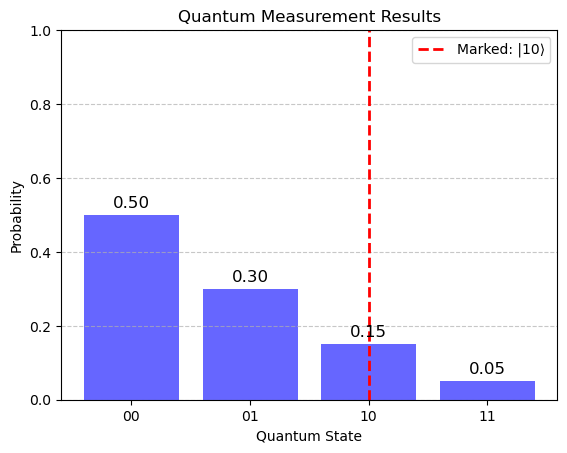

In [4]:
import matplotlib.pyplot as plt

# Example: Counts from a quantum measurement
counts = {'00': 500, '01': 300, '10': 150, '11': 50}

# Extract states and counts
states = list(counts.keys())  # Binary state labels
values = list(counts.values())  # Counts (or probabilities)

# Normalize counts to probabilities (optional)
total_counts = sum(values)
probabilities = [v / total_counts for v in values]

# Plot
plt.bar(states, probabilities, color='blue', alpha=0.6)
plt.xlabel('Quantum State')
plt.ylabel('Probability')
plt.title('Quantum Measurement Results')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show values on top of bars
for i, v in enumerate(probabilities):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=12)

# Mark a specific state with a vertical line
marked_state = "10"  # Example: Marking state |10⟩
if marked_state in states:
    marked_index = states.index(marked_state)  # Find its index
    plt.axvline(x=marked_index, color='red', linestyle='--', linewidth=2, label=f'Marked: |{marked_state}⟩')

# Add legend
plt.legend()

plt.show()
